In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("../data/VitaminD_Dataset.csv")

df = df.drop(["Skin_tone", "Sunscreen_Use"], axis=1)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 15)


,Age,Gender,Weight_kg,Height_cm,BMI,BodyFat_percent,Sun_Exposure_min,Skin_Exposure_percent,Alcohol_units_week,Fish_intake_week,Dairy_intake_week,Physical_activity_hours_week,Indoor_work_hours_day,VitaminD_Level_ng_ml,VitaminD_Category
0,63,0,72.3,167.2,25.9,40.2,5,34,2,3,5,4.8,7.3,7.7,Deficient
1,20,0,81.9,168.4,28.9,33.9,39,63,1,2,5,2.0,6.7,28.0,Insufficient
2,46,1,79.5,160.8,30.7,31.2,7,36,1,4,4,4.5,4.0,12.1,Deficient
3,52,1,51.2,171.5,17.4,16.6,46,20,5,1,4,1.8,10.7,18.7,Deficient
4,56,0,60.2,155.4,24.9,37.4,5,53,0,5,1,6.3,6.9,19.6,Deficient


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           10000 non-null  int64  
 1   Gender                        10000 non-null  int64  
 2   Weight_kg                     10000 non-null  float64
 3   Height_cm                     10000 non-null  float64
 4   BMI                           10000 non-null  float64
 5   BodyFat_percent               10000 non-null  float64
 6   Sun_Exposure_min              10000 non-null  int64  
 7   Skin_Exposure_percent         10000 non-null  int64  
 8   Alcohol_units_week            10000 non-null  int64  
 9   Fish_intake_week              10000 non-null  int64  
 10  Dairy_intake_week             10000 non-null  int64  
 11  Physical_activity_hours_week  10000 non-null  float64
 12  Indoor_work_hours_day         10000 non-null  float64
 13  Vi

Age                             0
Gender                          0
Weight_kg                       0
Height_cm                       0
BMI                             0
BodyFat_percent                 0
Sun_Exposure_min                0
Skin_Exposure_percent           0
Alcohol_units_week              0
Fish_intake_week                0
Dairy_intake_week               0
Physical_activity_hours_week    0
Indoor_work_hours_day           0
VitaminD_Level_ng_ml            0
VitaminD_Category               0
dtype: int64

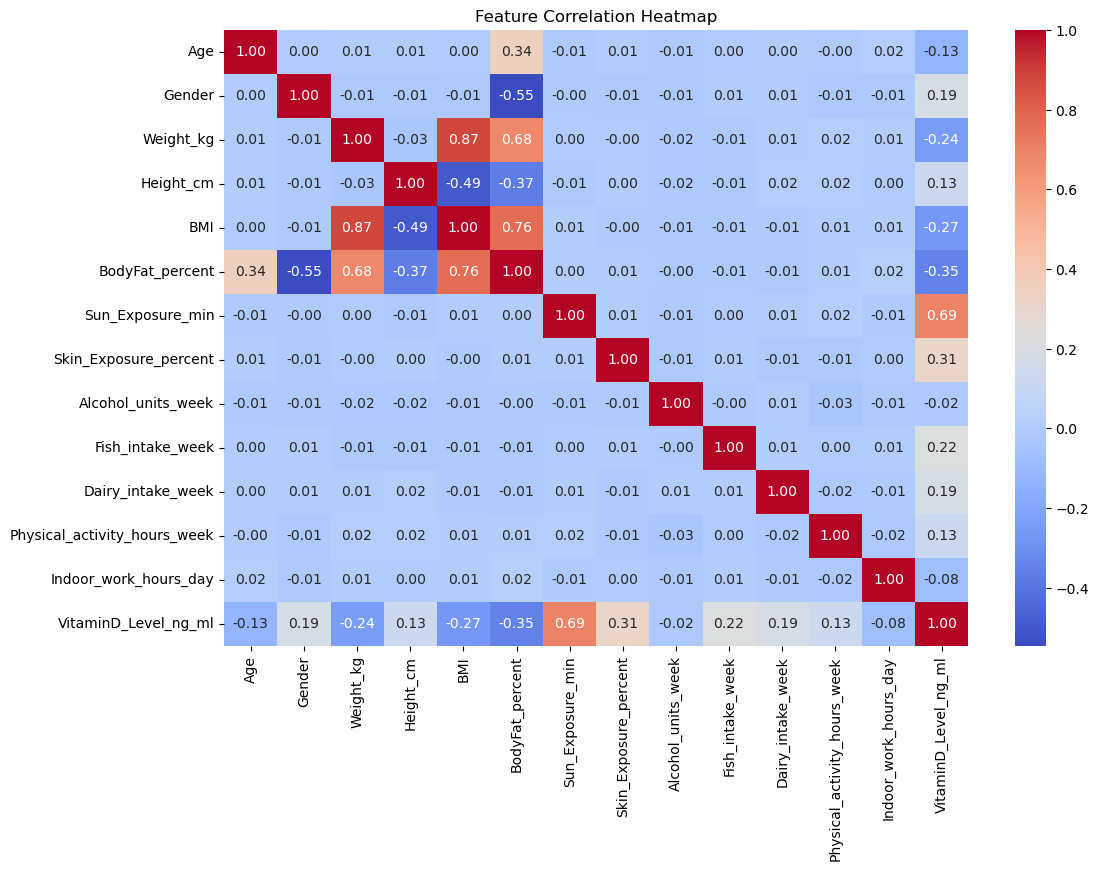

In [4]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:

obj_cols = df.select_dtypes(include="object").columns.tolist()
exclude_cols = ["Deficiency_Status", "VitaminD_Category", "VitaminD_Level_ng_ml"]

for col in obj_cols:
    if col not in exclude_cols:
        df[col] = LabelEncoder().fit_transform(df[col])

print("Encoded categorical columns:", [c for c in obj_cols if c not in exclude_cols])

Encoded categorical columns: []


In [6]:
print(df.columns)

Index(['Age', 'Gender', 'Weight_kg', 'Height_cm', 'BMI', 'BodyFat_percent',
       'Sun_Exposure_min', 'Skin_Exposure_percent', 'Alcohol_units_week',
       'Fish_intake_week', 'Dairy_intake_week', 'Physical_activity_hours_week',
       'Indoor_work_hours_day', 'VitaminD_Level_ng_ml', 'VitaminD_Category'],
      dtype='object')


In [ ]:

df = df.drop(["VitaminD_Category", "Skin_tone", "Sunscreen_Use"], axis=1, errors="ignore")

In [ ]:

target_col = "Risk_Score" if "Risk_Score" in df.columns else "VitaminD_Level_ng_ml"

X = df.drop(columns=[target_col], errors="ignore")


X = X.drop(columns=["Deficiency_Status"], errors="ignore")

X = pd.get_dummies(X, drop_first=True)

y = pd.to_numeric(df[target_col], errors="coerce")

if y.isna().any():
    target_encoder = LabelEncoder()
    y = pd.Series(
        target_encoder.fit_transform(df[target_col].astype(str)),
        index=df.index
    )
    print("Encoded target classes:", list(target_encoder.classes_))

print("Target column:", target_col)
print("Features used:")
print(X.columns)

Target column: VitaminD_Level_ng_ml
Features used:
Index(['Age', 'Gender', 'Weight_kg', 'Height_cm', 'BMI', 'BodyFat_percent',
       'Sun_Exposure_min', 'Skin_Exposure_percent', 'Alcohol_units_week',
       'Fish_intake_week', 'Dairy_intake_week', 'Physical_activity_hours_week',
       'Indoor_work_hours_day'],
      dtype='object')


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (8000, 13)
Testing samples: (2000, 13)


In [10]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression Results")

print("R2 Score:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

Linear Regression Results
R2 Score: 0.787506544656003
MAE: 3.4058123943486027
RMSE: 4.266162467726401


In [11]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [12]:
print("Random Forest Results")

print("R2 Score:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Random Forest Results
R2 Score: 0.7527804428650661
MAE: 3.6807327499999998
RMSE: 4.601569897939724


In [13]:
try:
    from xgboost import XGBRegressor
except Exception as e:
    raise ImportError(
        "XGBoost import failed in this kernel. Switch to a clean kernel or reinstall xgboost in the active kernel environment. "
        f"Original error: {e}"
    )

xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse"
    )

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("XGBoost Results")
print("R2 Score:", r2_score(y_test, xgb_pred))
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

XGBoost Results
R2 Score: 0.7759075315815949
MAE: 3.5185815296649934
RMSE: 4.381050320974453


In [14]:
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

print("Gradient Boosting Results")
print("R2 Score:", r2_score(y_test, gbr_pred))
print("MAE:", mean_absolute_error(y_test, gbr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gbr_pred)))

Gradient Boosting Results
R2 Score: 0.7786692290656584
MAE: 3.49224862480216
RMSE: 4.353970775614154


In [15]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gbr_pred),
        r2_score(y_test, xgb_pred),
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gbr_pred),
        mean_absolute_error(y_test, xgb_pred),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gbr_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred)),
    ]
})

results.sort_values("R2 Score", ascending=False)

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.787507,3.405812,4.266162
2,Gradient Boosting,0.778669,3.492249,4.353971
3,XGBoost,0.775908,3.518582,4.381050
1,Random Forest,0.752780,3.680733,4.601570


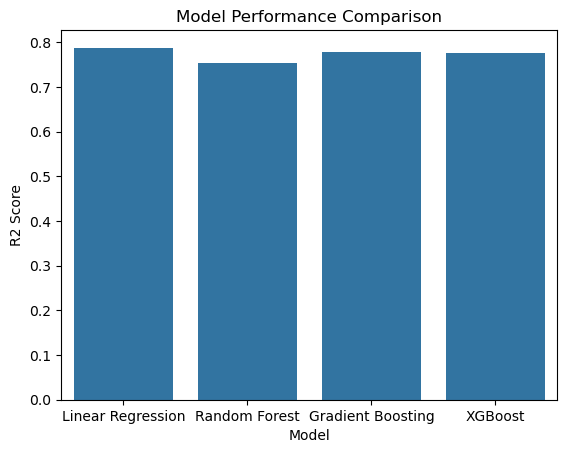

In [16]:
sns.barplot(x="Model", y="R2 Score", data=results)

plt.title("Model Performance Comparison")
plt.show()

In [17]:
importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,Sun_Exposure_min,0.498257
5,BodyFat_percent,0.151719
7,Skin_Exposure_percent,0.114644
9,Fish_intake_week,0.044298
11,Physical_activity_hours_week,0.037035
10,Dairy_intake_week,0.036686
12,Indoor_work_hours_day,0.025958
3,Height_cm,0.021446
0,Age,0.020058
2,Weight_kg,0.019463


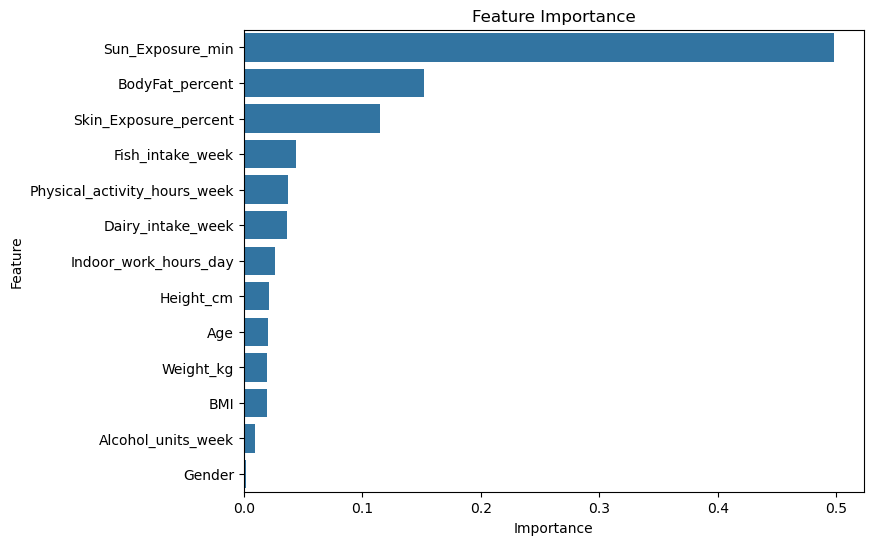

In [18]:
plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

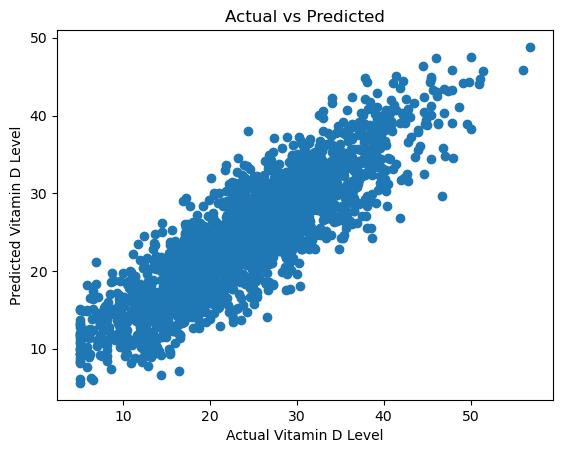

In [19]:
plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Vitamin D Level")
plt.ylabel("Predicted Vitamin D Level")

plt.title("Actual vs Predicted")

plt.show()

In [20]:
# ---------- Custom Dataset: Person-level prediction ----------
new_person_custom = pd.DataFrame({
    "Age": [25],
    "Gender": [1],
    "BMI": [24],
    "BodyFat_percent": [18],
    "Sun_Exposure_min": [25],
    "Skin_Exposure_percent": [40],
    "Fish_intake_week": [0],
    "Dairy_intake_week": [5],
    "Alcohol_units_week": [0],
    "Physical_activity_hours_week": [3],
    "Indoor_work_hours_day": [6]
})

# Align with the exact feature set used when rf was fitted.
custom_model_features = list(rf.feature_names_in_) if hasattr(rf, "feature_names_in_") else list(X.columns)
new_person_custom = new_person_custom.reindex(columns=custom_model_features, fill_value=0)

custom_prediction = rf.predict(new_person_custom)
custom_level = float(custom_prediction[0])

# Clinical threshold: < 20 ng/mL = Vitamin D deficient
custom_is_deficient = custom_level < 20
custom_deficiency_label = "Deficient" if custom_is_deficient else "Not Deficient"

print("Custom Dataset -> Predicted Vitamin D Level (ng/mL):", custom_level)
print("Custom Dataset -> Deficiency Prediction:", custom_deficiency_label)

Custom Dataset -> Predicted Vitamin D Level (ng/mL): 24.632999999999974
Custom Dataset -> Deficiency Prediction: Not Deficient


In [21]:
# ---------- NHANES Dataset: Same regression pipeline as above ----------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer

try:
    from xgboost import XGBRegressor
except Exception as e:
    raise ImportError(
        "XGBoost import failed in this kernel. Please reinstall in active environment. "
        f"Original error: {e}"
    )

# 1. Load NHANES 2017-2018 data
urls = {
    "demo": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DEMO_J.XPT",
    "vit_d": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/VID_J.XPT",
    "body": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.XPT",
    "activity": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/PAQ_J.XPT"
}

df_demo = pd.read_sas(urls["demo"])
df_vit = pd.read_sas(urls["vit_d"])
df_body = pd.read_sas(urls["body"])
df_act = pd.read_sas(urls["activity"])

df_nhanes = pd.merge(df_demo, df_vit, on="SEQN")
df_nhanes = pd.merge(df_nhanes, df_body, on="SEQN")
df_nhanes = pd.merge(df_nhanes, df_act, on="SEQN")

# 2. Feature and target setup (same style as custom pipeline)
nh_target_col = "LBXVIDMS"  # Serum vitamin D in nmol/L
base_features = ["RIDAGEYR", "RIAGENDR", "RIDRETH3", "BMXBMI"]
activity_candidates = ["PAQ710", "PAQ635", "PAQ650", "PAD680"]
activity_feature = next((c for c in activity_candidates if c in df_nhanes.columns), None)

nh_features = base_features.copy()
if activity_feature is not None:
    nh_features.append(activity_feature)
    print("Using activity feature:", activity_feature)
else:
    print("No expected activity feature found; using 4-feature NHANES model.")

# 3. NHANES noise cleaning
raw_rows = len(df_nhanes)

df_nhanes = df_nhanes.drop_duplicates(subset=["SEQN"]).copy()

# Keep only model columns for cleaning/feature engineering
model_cols = nh_features + [nh_target_col]
df_nhanes = df_nhanes[model_cols].copy()

# Convert to numeric and map NHANES non-response codes to NaN
special_missing_codes = [7, 9, 77, 99, 777, 999, 7777, 9999]
for col in df_nhanes.columns:
    df_nhanes[col] = pd.to_numeric(df_nhanes[col], errors="coerce")
    df_nhanes[col] = df_nhanes[col].replace(special_missing_codes, np.nan)

# Basic physiologic/data-validity filters
if "RIDAGEYR" in df_nhanes.columns:
    df_nhanes = df_nhanes[df_nhanes["RIDAGEYR"].between(0, 80, inclusive="both") | df_nhanes["RIDAGEYR"].isna()]
if "BMXBMI" in df_nhanes.columns:
    df_nhanes = df_nhanes[df_nhanes["BMXBMI"].between(10, 80, inclusive="both") | df_nhanes["BMXBMI"].isna()]

# Keep plausible vitamin D values only
if nh_target_col in df_nhanes.columns:
    df_nhanes = df_nhanes[df_nhanes[nh_target_col].between(5, 250, inclusive="both") | df_nhanes[nh_target_col].isna()]

# Winsorize continuous columns with IQR clipping to reduce outlier leverage
def iqr_clip(s: pd.Series) -> pd.Series:
    if s.dropna().empty:
        return s
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        return s
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return s.clip(lower=low, upper=high)

clip_cols = ["RIDAGEYR", "BMXBMI", nh_target_col]
if activity_feature is not None:
    clip_cols.append(activity_feature)

for col in clip_cols:
    if col in df_nhanes.columns:
        df_nhanes[col] = iqr_clip(df_nhanes[col])

clean_rows = len(df_nhanes)
print(f"Rows before cleaning: {raw_rows}")
print(f"Rows after cleaning:  {clean_rows}")
print(f"Rows removed:         {raw_rows - clean_rows}")
print("Missing values after cleaning:")
print(df_nhanes[model_cols].isna().sum())

# 4. Build X/y after cleaning
df_nhanes = df_nhanes.dropna(subset=[nh_target_col])
X_nh = df_nhanes[nh_features].copy()
y_nh = pd.to_numeric(df_nhanes[nh_target_col], errors="coerce")

X_nh = pd.get_dummies(X_nh, drop_first=True)

valid_idx = y_nh.notna()
X_nh = X_nh.loc[valid_idx]
y_nh = y_nh.loc[valid_idx]

nh_imputer = SimpleImputer(strategy="median")
X_nh_imputed = pd.DataFrame(
    nh_imputer.fit_transform(X_nh),
    columns=X_nh.columns,
    index=X_nh.index
)

X_nh_train, X_nh_test, y_nh_train, y_nh_test = train_test_split(
    X_nh_imputed, y_nh, test_size=0.2, random_state=42
)

# 5. Train same model family as custom pipeline
nh_lr = LinearRegression()
nh_rf = RandomForestRegressor(n_estimators=200, random_state=42)
nh_gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
nh_xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse"
)

nh_models = {
    "Linear Regression": nh_lr,
    "Random Forest": nh_rf,
    "Gradient Boosting": nh_gbr,
    "XGBoost": nh_xgb,
}

nh_rows = []
nh_predictions = {}

for name, model in nh_models.items():
    model.fit(X_nh_train, y_nh_train)
    preds = model.predict(X_nh_test)
    nh_predictions[name] = preds

    nh_rows.append({
        "Model": name,
        "R2 Score": r2_score(y_nh_test, preds),
        "MAE": mean_absolute_error(y_nh_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_nh_test, preds)),
    })

nhanes_results = pd.DataFrame(nh_rows).sort_values("R2 Score", ascending=False).reset_index(drop=True)
print("NHANES Regression Results")
display(nhanes_results)

# 6. NHANES clinical prediction for a sample person (nmol/L scale)
new_person_nhanes = pd.DataFrame({
    "RIDAGEYR": [25],
    "RIAGENDR": [1],
    "RIDRETH3": [3],
    "BMXBMI": [24],
})

if activity_feature is not None:
    new_person_nhanes[activity_feature] = 3

nh_model_features = list(nh_rf.feature_names_in_) if hasattr(nh_rf, "feature_names_in_") else list(X_nh.columns)
new_person_nhanes = new_person_nhanes.reindex(columns=nh_model_features, fill_value=0)

nh_prediction = nh_rf.predict(new_person_nhanes)
nh_level_nmol = float(nh_prediction[0])
nh_level_ng = nh_level_nmol / 2.5
nh_is_deficient = nh_level_nmol < 50
nh_deficiency_label = "Deficient" if nh_is_deficient else "Not Deficient"

print("NHANES -> Predicted Vitamin D Level (nmol/L):", nh_level_nmol)
print("NHANES -> Predicted Vitamin D Level (ng/mL):", nh_level_ng)
print("NHANES -> Deficiency Prediction:", nh_deficiency_label)

# 7. Compare both datasets while keeping pipelines separate
custom_best = results.sort_values("R2 Score", ascending=False).iloc[0]
nhanes_best = nhanes_results.sort_values("R2 Score", ascending=False).iloc[0]

dataset_comparison = pd.DataFrame([
    {
        "Dataset": "Custom",
        "Target Unit": "ng/mL",
        "Best Model": custom_best["Model"],
        "Best R2": custom_best["R2 Score"],
        "Best MAE": custom_best["MAE"],
        "Best RMSE": custom_best["RMSE"],
        "Sample Clinical Prediction": custom_deficiency_label,
    },
    {
        "Dataset": "NHANES",
        "Target Unit": "nmol/L",
        "Best Model": nhanes_best["Model"],
        "Best R2": nhanes_best["R2 Score"],
        "Best MAE": nhanes_best["MAE"],
        "Best RMSE": nhanes_best["RMSE"],
        "Sample Clinical Prediction": nh_deficiency_label,
    },
])

print("\nCustom vs NHANES (separate pipelines, same model family)")
display(dataset_comparison)

Using activity feature: PAQ635
Rows before cleaning: 5533
Rows after cleaning:  5527
Rows removed:         6
Missing values after cleaning:
RIDAGEYR     46
RIAGENDR      0
RIDRETH3    288
BMXBMI       98
PAQ635        0
LBXVIDMS    319
dtype: int64
NHANES Regression Results


,Model,R2 Score,MAE,RMSE
0,Gradient Boosting,0.240441,19.666633,25.172109
1,XGBoost,0.211793,20.101473,25.642421
2,Linear Regression,0.163773,20.947397,26.411981
3,Random Forest,0.115295,21.189708,27.166785


NHANES -> Predicted Vitamin D Level (nmol/L): 52.18799999999998
NHANES -> Predicted Vitamin D Level (ng/mL): 20.875199999999992
NHANES -> Deficiency Prediction: Not Deficient

Custom vs NHANES (separate pipelines, same model family)


,Dataset,Target Unit,Best Model,Best R2,Best MAE,Best RMSE,Sample Clinical Prediction
0,Custom,ng/mL,Linear Regression,0.787507,3.405812,4.266162,Not Deficient
1,NHANES,nmol/L,Gradient Boosting,0.240441,19.666633,25.172109,Not Deficient


In [21]:
import joblib

joblib.dump(rf, "model.pkl")

['model.pkl']